# K-Nearest Neighbors from First Principles with pandas and scikit-learn

This 3-hour laboratory studies k-nearest neighbors (k-NN) as an instance-based classifier.

By the end of the lab you should be able to:

- compute a k-NN prediction from distances and neighbor votes;
- train and evaluate `KNeighborsClassifier` models;
- choose `k`, distance weighting, and a distance metric using validation data;
- explain why feature scaling is essential for distance-based learning;
- build a preprocessing-and-modeling pipeline that avoids data leakage.

## 0. Setup

In [1]:
#| echo: false
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    log_loss,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

Matplotlib is building the font cache; this may take a moment.


## 1. Distance warm-up - 20 minutes

k-NN does not fit a parametric model. At prediction time it:

1. computes the distance between the query point and the training records;
2. selects the `k` closest records;
3. predicts by majority vote, or by distance-weighted vote.

We start with a tiny customer-churn example so every number is visible.

In [2]:
#| echo: false
customers = pd.DataFrame({
    "customer": ["A", "B", "C", "D", "E", "query"],
    "weekly_sessions": [2, 3, 8, 9, 10, 7],
    "support_tickets": [8, 7, 2, 3, 1, 4],
    "label": ["churn", "churn", "stay", "stay", "stay", None],
})
customers

,customer,weekly_sessions,support_tickets,label
0,A,2,8,churn
1,B,3,7,churn
2,C,8,2,stay
3,D,9,3,stay
4,E,10,1,stay
5,query,7,4,NaN


## Manual Euclidean distances

In [3]:
#| echo: false
query = customers.query("customer == 'query'")[["weekly_sessions", "support_tickets"]].to_numpy()[0]
train_customers = customers.dropna(subset=["label"]).copy()
X_toy = train_customers[["weekly_sessions", "support_tickets"]].to_numpy()

train_customers["distance_to_query"] = np.sqrt(((X_toy - query) ** 2).sum(axis=1))
train_customers.sort_values("distance_to_query")

,customer,weekly_sessions,support_tickets,label,distance_to_query
3,D,9,3,stay,2.236068
2,C,8,2,stay,2.236068
4,E,10,1,stay,4.242641
1,B,3,7,churn,5.000000
0,A,2,8,churn,6.403124


## Visualize the neighborhood

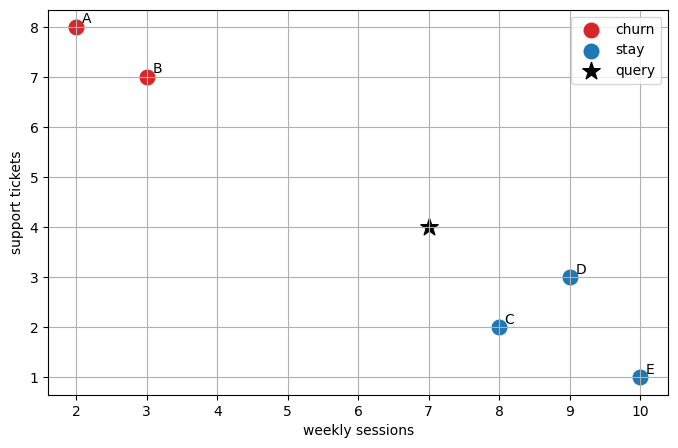

In [4]:
#| echo: false
colors = {"churn": "tab:red", "stay": "tab:blue"}
fig, ax = plt.subplots()
for label, group in train_customers.groupby("label"):
    ax.scatter(group["weekly_sessions"], group["support_tickets"], s=110, label=label, color=colors[label])
for _, row in train_customers.iterrows():
    ax.annotate(row["customer"], (row["weekly_sessions"] + 0.08, row["support_tickets"] + 0.08))
ax.scatter(query[0], query[1], s=170, marker="*", color="black", label="query")
ax.set_xlabel("weekly sessions")
ax.set_ylabel("support tickets")
ax.legend()
plt.show()

### Exercise 1 - vote by hand (8 minutes)

Use the table of distances above.

1. What label is predicted when `k=1`?
2. What label is predicted when `k=3`?
3. What label is predicted when `k=5`?
4. Which prediction would you trust more? Why?

## Weighted vote

With `weights="distance"`, closer neighbors have more influence. A common intuition is that a neighbor at distance 1 should matter more than a neighbor at distance 5.

In [5]:
#| echo: false
neighbors = train_customers.sort_values("distance_to_query").head(3).copy()
neighbors["inverse_distance_weight"] = 1 / neighbors["distance_to_query"]
weighted_vote = neighbors.groupby("label")["inverse_distance_weight"].sum().sort_values(ascending=False)
display(neighbors[["customer", "label", "distance_to_query", "inverse_distance_weight"]])
display(weighted_vote.to_frame("total_weight"))

,customer,label,distance_to_query,inverse_distance_weight
3,D,stay,2.236068,0.447214
2,C,stay,2.236068,0.447214
4,E,stay,4.242641,0.235702


,total_weight
label,
stay,1.130129


## 2. Iris warm-up: decision regions - 25 minutes

The Iris dataset is small enough to visualize in two dimensions. We will use only petal length and petal width for the first experiment.

In [6]:
#| echo: false
iris = load_iris(as_frame=True)
iris_df = iris.frame.rename(columns={"target": "species_id"})
iris_df["species"] = iris_df["species_id"].map(dict(enumerate(iris.target_names)))
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Iris feature space

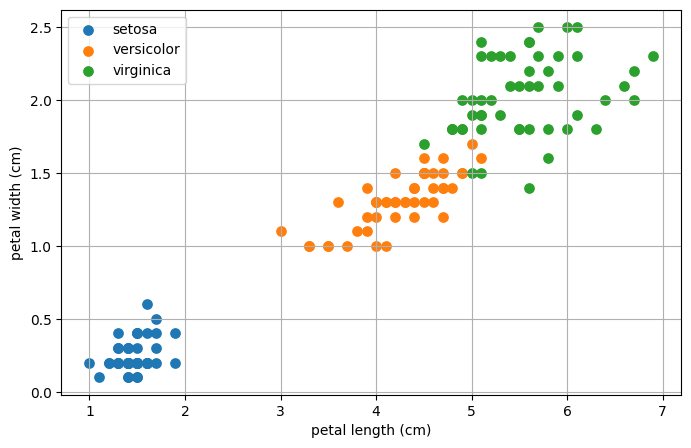

In [7]:
#| echo: false
iris_features = ["petal length (cm)", "petal width (cm)"]
fig, ax = plt.subplots()
for species, group in iris_df.groupby("species"):
    ax.scatter(group[iris_features[0]], group[iris_features[1]], label=species, s=45)
ax.set_xlabel(iris_features[0])
ax.set_ylabel(iris_features[1])
ax.legend()
plt.show()

## Decision boundary helper

In [8]:
#| echo: false
def plot_knn_boundary(model, X, y, title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(8, 5))
    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method="predict",
        cmap="Pastel1",
        alpha=0.6,
        ax=ax,
        grid_resolution=250,
    )
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap="Set1", s=35)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return ax

## Iris boundary: k = 1

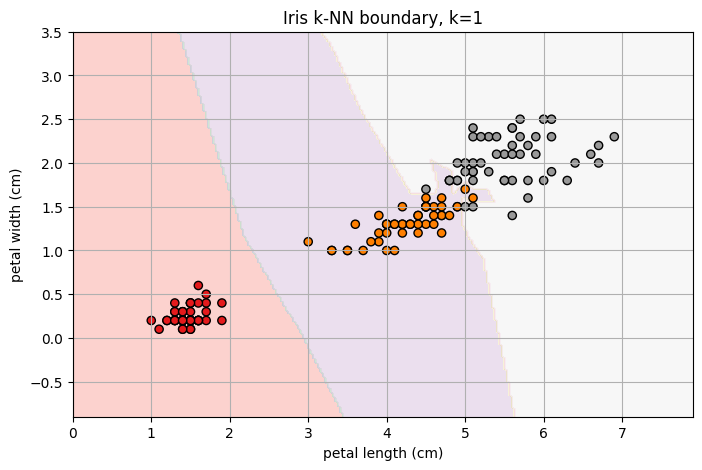

In [9]:
#| echo: false
X_iris_2d = iris_df[iris_features].to_numpy()
y_iris = iris_df["species_id"].to_numpy()
knn_1 = KNeighborsClassifier(n_neighbors=1).fit(X_iris_2d, y_iris)
plot_knn_boundary(knn_1, X_iris_2d, y_iris, "Iris k-NN boundary, k=1", iris_features[0], iris_features[1]);

## Iris boundary: k = 15

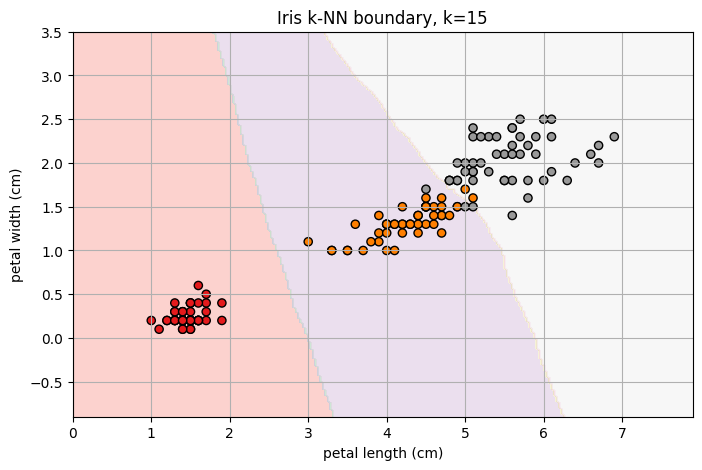

In [10]:
#| echo: false
knn_15 = KNeighborsClassifier(n_neighbors=15).fit(X_iris_2d, y_iris)
plot_knn_boundary(knn_15, X_iris_2d, y_iris, "Iris k-NN boundary, k=15", iris_features[0], iris_features[1]);

### Checkpoint

Compare the two boundaries.

- Which one follows individual points more closely?
- Which one is smoother?
- Which one is more likely to overfit noisy labels?

## 3. Load and split the breast-cancer dataset - 15 minutes

We now move to a realistic binary classification task. The target is whether a tumor is malignant or benign.

In [11]:
#| echo: false
cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = cancer.target
class_names = dict(enumerate(cancer.target_names))
print(X.shape)
display(X.head())
display(pd.Series(y).map(class_names).value_counts().to_frame("count"))

(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,count
target,
benign,357
malignant,212


## Feature ranges

k-NN is driven by distances. Before training anything, inspect whether all features live on comparable scales.

In [12]:
#| echo: false
feature_ranges = pd.DataFrame({
    "min": X.min(),
    "max": X.max(),
    "range": X.max() - X.min(),
    "std": X.std(),
}).sort_values("range", ascending=False)
feature_ranges.head(12)

,min,max,range,std
worst area,185.2000,4254.000,4068.8000,569.356993
mean area,143.5000,2501.000,2357.5000,351.914129
area error,6.8020,542.200,535.3980,45.491006
worst perimeter,50.4100,251.200,200.7900,33.602542
mean perimeter,43.7900,188.500,144.7100,24.298981
worst texture,12.0200,49.540,37.5200,6.146258
mean texture,9.7100,39.280,29.5700,4.301036
worst radius,7.9300,36.040,28.1100,4.833242
perimeter error,0.7570,21.980,21.2230,2.021855
mean radius,6.9810,28.110,21.1290,3.524049


## One fixed train/test split

In [13]:
#| echo: false
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)
print("train", X_train.shape, "test", X_test.shape)
display(pd.Series(y_train).map(class_names).value_counts(normalize=True).rename("train proportion"))
display(pd.Series(y_test).map(class_names).value_counts(normalize=True).rename("test proportion"))

train (426, 30) test (143, 30)


target
benign       0.626761
malignant    0.373239
Name: train proportion, dtype: float64

target
benign       0.629371
malignant    0.370629
Name: test proportion, dtype: float64

## 4. First k-NN model: intentionally unscaled - 20 minutes

This first model is deliberately incomplete. It shows what happens when Euclidean distance is computed on raw feature units.

In [14]:
#| echo: false
raw_knn = KNeighborsClassifier(n_neighbors=5)
raw_knn.fit(X_train, y_train)
raw_pred = raw_knn.predict(X_test)
raw_proba = raw_knn.predict_proba(X_test)

raw_scores = pd.Series({
    "accuracy": accuracy_score(y_test, raw_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, raw_pred),
    "f1": f1_score(y_test, raw_pred),
    "log_loss": log_loss(y_test, raw_proba),
})
raw_scores.to_frame("raw k-NN")

,raw k-NN
accuracy,0.930070
balanced_accuracy,0.921174
f1,0.945055
log_loss,0.841711


## First k-NN confusion matrix

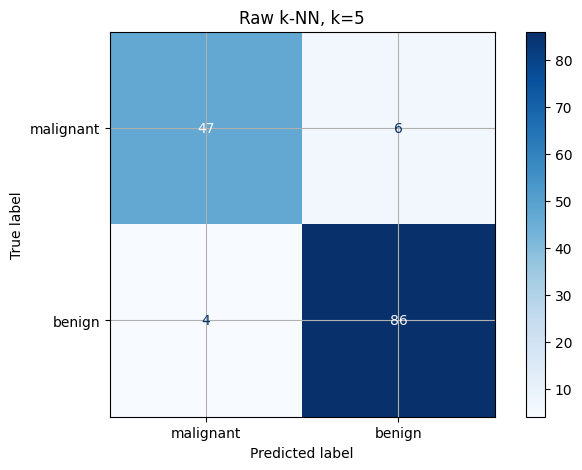

In [15]:
#| echo: false
ConfusionMatrixDisplay.from_predictions(y_test, raw_pred, display_labels=cancer.target_names, cmap="Blues")
plt.title("Raw k-NN, k=5")
plt.show()

## 5. Feature scaling changes the geometry - 30 minutes

Standardization transforms each feature so that the training-set mean is 0 and the training-set standard deviation is 1.

Important: fit the scaler on the training set only. The test set must remain unseen during preprocessing.

In [16]:
#| echo: false
scaled_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5)),
])
scaled_knn.fit(X_train, y_train)
scaled_pred = scaled_knn.predict(X_test)
scaled_proba = scaled_knn.predict_proba(X_test)

scaled_scores = pd.Series({
    "accuracy": accuracy_score(y_test, scaled_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, scaled_pred),
    "f1": f1_score(y_test, scaled_pred),
    "log_loss": log_loss(y_test, scaled_proba),
})
pd.concat([raw_scores, scaled_scores], axis=1, keys=["raw k-NN", "scaled k-NN"])

,raw k-NN,scaled k-NN
accuracy,0.930070,0.979021
balanced_accuracy,0.921174,0.971698
f1,0.945055,0.983607
log_loss,0.841711,0.332417


## Why the neighbors changed

The model can predict differently after scaling because the nearest records are no longer necessarily the same records.

In [17]:
#| echo: false
query_idx = X_test.index[0]
query_raw = X_test.loc[[query_idx]]

raw_nn = NearestNeighbors(n_neighbors=5).fit(X_train)
raw_dist, raw_ind = raw_nn.kneighbors(query_raw)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
query_scaled = scaler.transform(query_raw)
scaled_nn = NearestNeighbors(n_neighbors=5).fit(X_train_scaled)
scaled_dist, scaled_ind = scaled_nn.kneighbors(query_scaled)

y_train_series = pd.Series(y_train, index=X_train.index)
neighbor_comparison = pd.DataFrame({
    "raw_neighbor_index": X_train.index[raw_ind[0]],
    "raw_distance": raw_dist[0],
    "raw_label": y_train_series.iloc[raw_ind[0]].map(class_names).to_numpy(),
    "scaled_neighbor_index": X_train.index[scaled_ind[0]],
    "scaled_distance": scaled_dist[0],
    "scaled_label": y_train_series.iloc[scaled_ind[0]].map(class_names).to_numpy(),
})
neighbor_comparison

,raw_neighbor_index,raw_distance,raw_label,scaled_neighbor_index,scaled_distance,scaled_label
0,312,13.726455,benign,502,1.976692,benign
1,79,15.618625,benign,249,2.148792,benign
2,436,16.337859,benign,221,2.193188,benign
3,454,18.257686,benign,422,2.205316,benign
4,331,24.862954,benign,394,2.234937,benign


### Exercise 2 - explain scaling (10 minutes)

Look at the feature-range table and the neighbor-comparison table.

1. Which raw features can dominate Euclidean distance?
2. Did the nearest neighbors change after scaling?
3. Why does a pipeline reduce the risk of data leakage?
4. Would feature scaling matter for a decision tree in the same way?

## Scaling example: a controlled synthetic dataset

In this synthetic dataset, feature `x_small_signal` contains the useful signal. Feature `x_large_noise` is mostly noise but has a much larger numeric range. Without scaling, the noisy feature can dominate distances.

In [18]:
#| echo: false
rng = np.random.default_rng(RANDOM_STATE)
n = 240
x_small = rng.normal(size=n)
y_synth = (x_small > 0).astype(int)
x_large_noise = rng.normal(scale=80, size=n)
X_synth = pd.DataFrame({"x_small_signal": x_small, "x_large_noise": x_large_noise})

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_synth,
    y_synth,
    test_size=0.3,
    stratify=y_synth,
    random_state=RANDOM_STATE,
)

raw_synth = KNeighborsClassifier(n_neighbors=7).fit(Xs_train, ys_train)
scaled_synth = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7)),
]).fit(Xs_train, ys_train)

pd.DataFrame({
    "model": ["raw", "scaled"],
    "accuracy": [
        accuracy_score(ys_test, raw_synth.predict(Xs_test)),
        accuracy_score(ys_test, scaled_synth.predict(Xs_test)),
    ],
})

,model,accuracy
0,raw,0.555556
1,scaled,1.000000


## Synthetic feature space

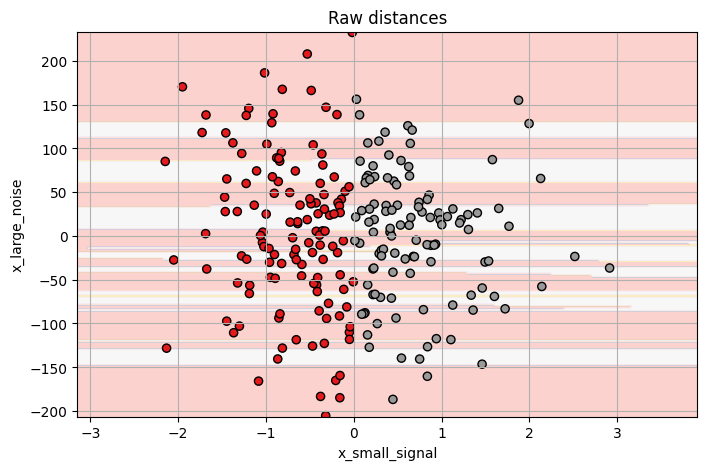

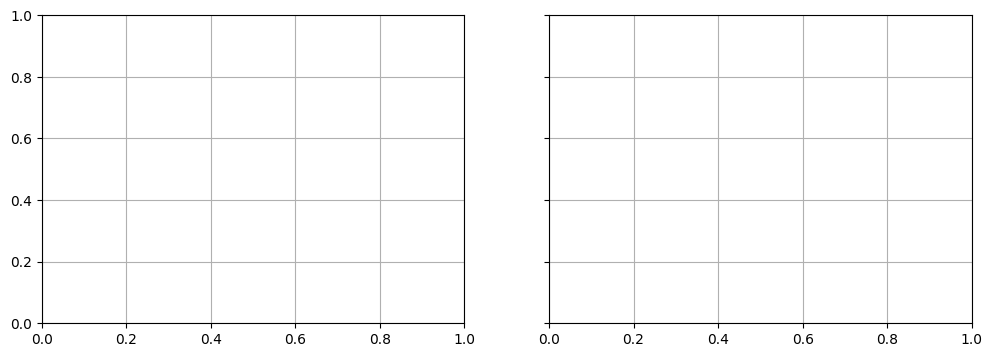

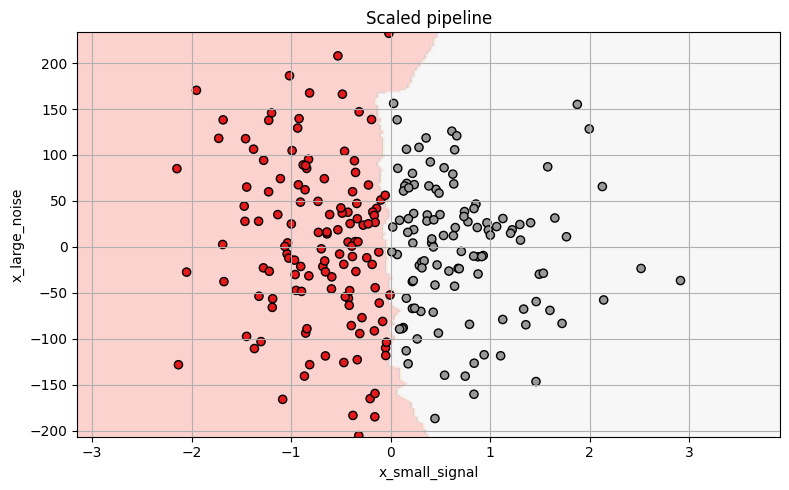

In [19]:
#| echo: false
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plt.sca(axes[0])
plot_knn_boundary(raw_synth, X_synth.to_numpy(), y_synth, "Raw distances", "x_small_signal", "x_large_noise")
plt.sca(axes[1])
plot_knn_boundary(scaled_synth, X_synth.to_numpy(), y_synth, "Scaled pipeline", "x_small_signal", "x_large_noise")
plt.tight_layout()
plt.show()

## 6. Select k with cross-validation - 30 minutes

The value of `k` controls the bias-variance trade-off.

- small `k`: flexible, local, sensitive to noise;
- large `k`: smoother, more stable, may underfit.

We choose `k` on training data using cross-validation. The test set is used once at the end.

In [20]:
#| echo: false
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for k in range(1, 32, 2):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "balanced_accuracy", "f1", "neg_log_loss"],
        n_jobs=-1,
    )
    results.append({
        "k": k,
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "f1": scores["test_f1"].mean(),
        "log_loss": -scores["test_neg_log_loss"].mean(),
    })

k_results = pd.DataFrame(results)
k_results.head()

,k,accuracy,balanced_accuracy,f1,log_loss
0,1,0.936662,0.930693,0.949835,2.282929
1,3,0.962435,0.953785,0.970670,0.728563
2,5,0.967114,0.958796,0.974373,0.489835
3,7,0.964788,0.955671,0.972604,0.257160
4,9,0.969494,0.961921,0.976141,0.263456


## Accuracy by k

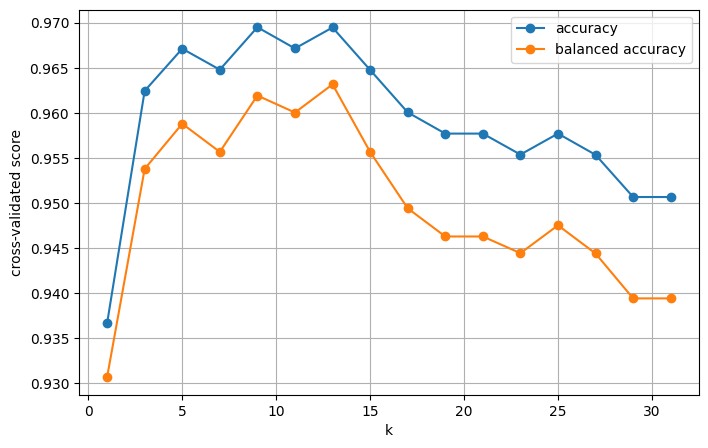

In [21]:
#| echo: false
fig, ax = plt.subplots()
ax.plot(k_results["k"], k_results["accuracy"], marker="o", label="accuracy")
ax.plot(k_results["k"], k_results["balanced_accuracy"], marker="o", label="balanced accuracy")
ax.set_xlabel("k")
ax.set_ylabel("cross-validated score")
ax.legend()
plt.show()

## Log loss by k

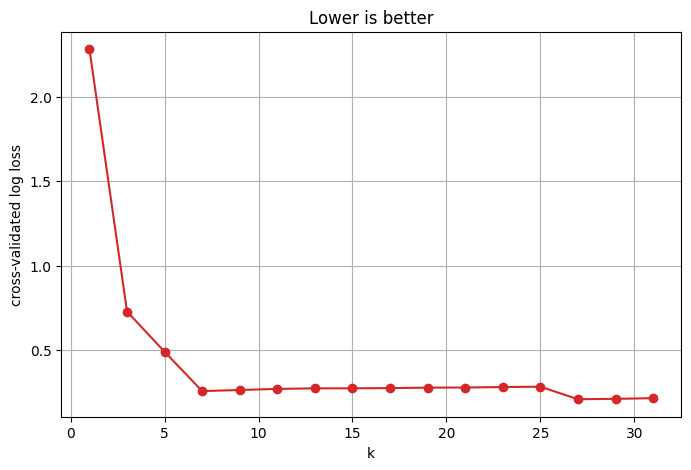

In [22]:
#| echo: false
fig, ax = plt.subplots()
ax.plot(k_results["k"], k_results["log_loss"], marker="o", color="tab:red")
ax.set_xlabel("k")
ax.set_ylabel("cross-validated log loss")
ax.set_title("Lower is better")
plt.show()

## Best k by validation score

In [23]:
#| echo: false
best_by_accuracy = k_results.sort_values("accuracy", ascending=False).head(5)
best_by_log_loss = k_results.sort_values("log_loss", ascending=True).head(5)
display(best_by_accuracy)
display(best_by_log_loss)

,k,accuracy,balanced_accuracy,f1,log_loss
4,9,0.969494,0.961921,0.976141,0.263456
6,13,0.969466,0.963160,0.975973,0.273513
5,11,0.967141,0.960035,0.974204,0.270078
2,5,0.967114,0.958796,0.974373,0.489835
3,7,0.964788,0.955671,0.972604,0.257160


,k,accuracy,balanced_accuracy,f1,log_loss
13,27,0.955349,0.944410,0.965559,0.208949
14,29,0.950670,0.939433,0.961919,0.211107
15,31,0.950670,0.939433,0.961919,0.215226
3,7,0.964788,0.955671,0.972604,0.257160
4,9,0.969494,0.961921,0.976141,0.263456


### Exercise 3 - choose k (10 minutes)

Use the validation curves.

1. Which `k` would you choose if the objective is accuracy?
2. Which `k` would you choose if probability quality matters and log loss is considered?
3. Is the best `k` necessarily the smallest or largest tested value?
4. Why should the test set not be used to choose `k`?

## 7. Compare distance weighting, metrics, and scalers - 25 minutes

Now we search several reasonable k-NN configurations with `GridSearchCV`.

In [24]:
#| echo: false
param_grid = {
    "scaler": [StandardScaler(), MinMaxScaler()],
    "knn__n_neighbors": list(range(1, 32, 2)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}
search = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())]),
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
search.fit(X_train, y_train)
print(search.best_score_)
search.best_params_

0.9650462962962962


{'knn__metric': 'euclidean',
 'knn__n_neighbors': 7,
 'knn__weights': 'uniform',
 'scaler': MinMaxScaler()}

## Grid-search results

In [25]:
#| echo: false
grid_results = pd.DataFrame(search.cv_results_)
cols = [
    "param_scaler", "param_knn__n_neighbors", "param_knn__weights", "param_knn__metric",
    "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score",
]
display(grid_results[cols].sort_values("rank_test_score").head(12))

,param_scaler,param_knn__n_neighbors,param_knn__weights,param_knn__metric,mean_train_score,mean_test_score,std_test_score,rank_test_score
13,MinMaxScaler(),7,uniform,euclidean,0.968133,0.965046,0.010787,1
15,MinMaxScaler(),7,distance,euclidean,1.000000,0.965046,0.010787,1
87,MinMaxScaler(),11,distance,manhattan,1.000000,0.965046,0.017654,1
85,MinMaxScaler(),11,uniform,manhattan,0.966078,0.965046,0.017654,1
19,MinMaxScaler(),9,distance,euclidean,1.000000,0.965011,0.016036,5
17,MinMaxScaler(),9,uniform,euclidean,0.967029,0.965011,0.016036,5
24,StandardScaler(),13,uniform,euclidean,0.959791,0.963160,0.010799,7
26,StandardScaler(),13,distance,euclidean,1.000000,0.963160,0.010799,7
79,MinMaxScaler(),7,distance,manhattan,1.000000,0.963160,0.013251,7
77,MinMaxScaler(),7,uniform,manhattan,0.969236,0.963160,0.013251,7


## Final tuned model on the test set

In [26]:
#| echo: false
best_knn = search.best_estimator_
best_pred = best_knn.predict(X_test)
best_proba = best_knn.predict_proba(X_test)
final_scores = pd.Series({
    "accuracy": accuracy_score(y_test, best_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, best_pred),
    "f1": f1_score(y_test, best_pred),
    "log_loss": log_loss(y_test, best_proba),
})
pd.concat([raw_scores, scaled_scores, final_scores], axis=1, keys=["raw k-NN", "scaled k=5", "tuned k-NN"])

,raw k-NN,scaled k=5,tuned k-NN
accuracy,0.930070,0.979021,0.965035
balanced_accuracy,0.921174,0.971698,0.956709
f1,0.945055,0.983607,0.972678
log_loss,0.841711,0.332417,0.094363


## Final confusion matrix

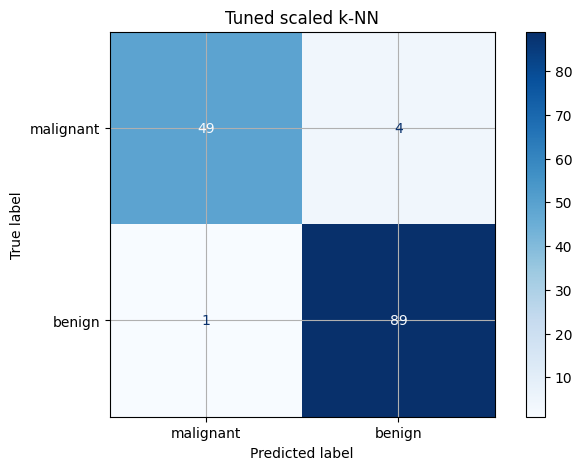

In [27]:
#| echo: false
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=cancer.target_names, cmap="Blues")
plt.title("Tuned scaled k-NN")
plt.show()

## Final classification report

In [28]:
#| echo: false
print(classification_report(y_test, best_pred, target_names=cancer.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.92      0.95        53
      benign       0.96      0.99      0.97        90

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



## 8. What happens with irrelevant features? - 20 minutes

k-NN is sensitive to irrelevant dimensions because every feature can contribute to distance. Scaling solves unequal units, but it does not decide which features are useful.

In [29]:
#| echo: false
rng = np.random.default_rng(RANDOM_STATE)
X_noise_train = X_train.copy()
X_noise_test = X_test.copy()
for i in range(20):
    X_noise_train[f"random_noise_{i:02d}"] = rng.normal(size=len(X_noise_train))
    X_noise_test[f"random_noise_{i:02d}"] = rng.normal(size=len(X_noise_test))

clean_model = search.best_estimator_
noisy_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=search.best_params_["knn__n_neighbors"],
        weights=search.best_params_["knn__weights"],
        metric=search.best_params_["knn__metric"],
    )),
])
noisy_model.fit(X_noise_train, y_train)
noisy_pred = noisy_model.predict(X_noise_test)

pd.DataFrame({
    "dataset": ["original features", "original + 20 random features"],
    "test_balanced_accuracy": [
        balanced_accuracy_score(y_test, clean_model.predict(X_test)),
        balanced_accuracy_score(y_test, noisy_pred),
    ],
    "test_f1": [
        f1_score(y_test, clean_model.predict(X_test)),
        f1_score(y_test, noisy_pred),
    ],
})

,dataset,test_balanced_accuracy,test_f1
0,original features,0.956709,0.972678
1,original + 20 random features,0.917296,0.945652


### Exercise 4 - diagnose irrelevant features (8 minutes)

1. Did adding random features help or hurt?
2. Why can scaling be necessary but still insufficient?
3. Which preprocessing or modeling strategies could reduce this problem?

## 9. Capstone tasks - 30 minutes

Work in pairs. Build a compact experimental report using the same train/test split.

Required tasks:

1. Compare raw k-NN, scaled k-NN, and tuned scaled k-NN.
2. Try at least three values of `k` that were not the best validation value.
3. Compare `StandardScaler` and `MinMaxScaler`.
4. Explain one prediction by listing its nearest neighbors before and after scaling.
5. Write a short conclusion: when would you use k-NN for this dataset?

In [30]:
# TODO: capstone workspace
# Suggested structure:
# 1. define candidate pipelines
# 2. evaluate with cross-validation on X_train/y_train
# 3. fit the selected model on X_train/y_train
# 4. evaluate once on X_test/y_test
# 5. inspect nearest neighbors for one selected test case

## Capstone helper: reusable evaluation function

In [31]:
#| echo: false
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)
    return pd.Series({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "log_loss": log_loss(y_test, proba),
    })

baseline_table = pd.DataFrame([
    evaluate_model("raw k=5", KNeighborsClassifier(n_neighbors=5), X_train, X_test, y_train, y_test),
    evaluate_model(
        "standard scaled k=5",
        Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))]),
        X_train, X_test, y_train, y_test,
    ),
    evaluate_model(
        "minmax scaled k=5",
        Pipeline([("scaler", MinMaxScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))]),
        X_train, X_test, y_train, y_test,
    ),
])
baseline_table

,model,accuracy,balanced_accuracy,f1,log_loss
0,raw k=5,0.930070,0.921174,0.945055,0.841711
1,standard scaled k=5,0.979021,0.971698,0.983607,0.332417
2,minmax scaled k=5,0.986014,0.981132,0.989011,0.078066


## 10. Key takeaways

- k-NN is an instance-based method: prediction depends on stored training examples.
- The distance metric defines what "similar" means.
- Feature scaling is essential because unscaled large-range features dominate Euclidean and Manhattan distances.
- Scaling must be fitted on the training set only; use `Pipeline` to make this automatic.
- `k`, weights, metric, and scaler are hyperparameters and should be selected with validation or cross-validation.
- Irrelevant features can still damage k-NN after scaling because they add noise to the distance calculation.
- Keep the test set untouched until the final evaluation.

## References

- scikit-learn documentation: `KNeighborsClassifier`, `Pipeline`, `StandardScaler`, `GridSearchCV`.
- Pang-Ning Tan, Michael Steinbach, and Vipin Kumar. *Introduction to Data Mining*. Pearson International, 2006.